In [ ]:
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from library.finite_difference import *

OUTDIR = Path('.')
%load_ext autoreload
%autoreload 2

In [ ]:
f = lambda x: np.exp(xdd) 
solve_d = upp_sovler_d()

solve_d.set_interval(0,1,1000)

start = ('dirichlet', 1.)
end = ('dirichlet', np.exp(1))
solve_d.set_boundary(start, end)

solve_d.set_f(f)

x, y = solve_d.solve()

solve_d.set_interval(0,1,1000)
solve_d.set_boundary(('dirichlet', 3.),('dirichlet', 3.*np.exp(1)))
solve_d.set_f(lambda t: 3*np.exp(t))

x2, y2 = solve_d.solve()




In [3]:
e = y - 1.*np.exp(x)
print(np.linalg.norm(e, ord=np.inf))

e2 = y2 - 3*np.exp(x2)
print(e2)
print(np.linalg.norm(e2, ord=np.inf))

1.765609525250511e-08
[0.00000000e+00 1.79449344e-10 3.58648222e-10 ... 4.98662445e-10
 2.49670506e-10 0.00000000e+00]
5.296826888212536e-08


In [4]:
f = np.exp
sigma = 0.0
beta = 3.
u_exact = lambda x: np.exp(x) -x + 4.0 - np.e

In [5]:
h = 1e-7
N = int(round(1/h))
start = ('neumann', sigma)
end = ('dirichlet', beta)

solve_n = {}
solve_n['n1'] = upp_solver_n1()
solve_n['n2'] = upp_solver_n2()
solve_n['n3'] = upp_solver_n3()
for n in [10, 100, 1000, 10000]:
    #N = int(round(1/h))
    N = n
    print(f"grid n:{n}")
    for type, solver in solve_n.items():
        solver.set_interval(0,1,N)
        solver.set_f(f)
        solver.set_boundary(start, end)
        x, y = solver.solve()
        e = y - u_exact(x)
        error_inf = np.linalg.norm(e, ord=np.inf)
        print(f"type: {type} error: {error_inf}")
        






grid n:10
type: n1 error: 0.05226438033446046
type: n2 error: 0.0022643803344619684
type: n3 error: 0.0029941655693228597
grid n:100
type: n1 error: 0.005022652263191318
type: n2 error: 2.2652263385936067e-05
type: n3 error: 2.7598573237419544e-05
grid n:1000
type: n1 error: 0.0005002265323943433
type: n2 error: 2.265193090877915e-07
type: n3 error: 2.7372631228317346e-07
grid n:10000
type: n1 error: 5.000237166186139e-05
type: n2 error: 2.254891828812333e-09
type: n3 error: 1.707344399193289e-08


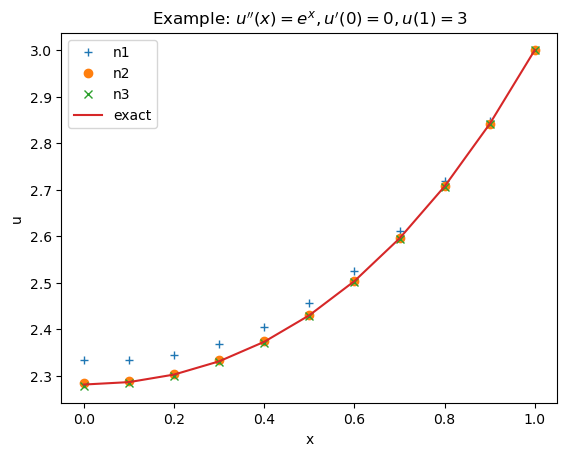

In [6]:
n = 10
fig, ax = plt.subplots()
marker = {'n1': '+', 'n2': 'o', 'n3': 'x'}

ax.plot()
for type, solver in solve_n.items():
    solver.set_n(n)
    x, y = solver.solve()
    ax.plot(x,y, marker=marker[type], linestyle='None', label=type)
ax.plot(x, u_exact(x), label='exact')

ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title("Example: $u''(x) = e^x, u'(0) =0, u(1) = 3$")

ax.legend()
plt.show()

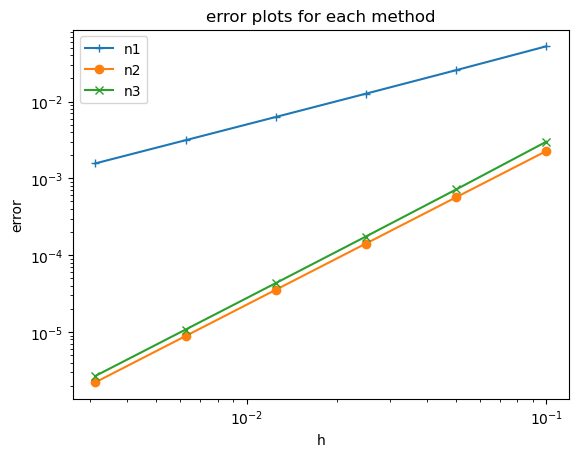

h: 0.10000 n1:5.22644e-02 n2:2.26438e-03 n3:2.99417e-03 
h: 0.05000 n1:2.55663e-02 n2:5.66255e-04 n3:7.15522e-04 
h: 0.02500 n1:1.26416e-02 n2:1.41574e-04 n3:1.74865e-04 
h: 0.01250 n1:6.28539e-03 n2:3.53941e-05 n3:4.32212e-05 
h: 0.00625 n1:3.13385e-03 n2:8.84856e-06 n3:1.07439e-05 
h: 0.00313 n1:1.56471e-03 n2:2.21214e-06 n3:2.67831e-06 


In [7]:
base = 0.1
hs = base * (0.5 ** np.arange(6))

fig, ax = plt.subplots()
error = {}

for type, solver in solve_n.items():
    err_list = []
    for h in hs:
        solver.set_interval(0,1,10)
        solver.set_h(h)
        x, y = solver.solve()
        e = np.linalg.norm(y - u_exact(x), ord=np.inf)
        err_list.append(e)
    error[type] = np.array(err_list)
    ax.loglog(hs, error[type], marker = marker[type], label=type)

    
ax.set_xlabel('h')
ax.set_ylabel('error')
ax.set_title("error plots for each method")
ax.legend()
plt.show()

for i in range(len(hs)):
    print(f"h:{hs[i]:8.5f}", end=' ')
    for type in solve_n.keys():
        print(f"{type}:{error[type][i]:8.5e}", end=' ')
    print()

0.7


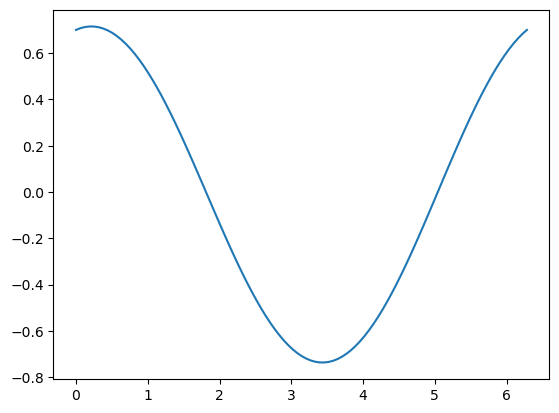

In [71]:
from scipy.linalg import norm
n = 100
alpha, beta = 0.7, 0.7
T = 2 * np.pi
max_it=1000
tol = 1e-10




x, h = np.linspace(0,T,n+1, retstep=True)
init_y = 0.7 * np.cos(x) + 0.5 * np.sin(x)
N = n-1
y = init_y[1:-1]
for _ in range(max_it):
    J = np.zeros((N,N))
    G = np.zeros(N)
    G[0] = (alpha-2*y[0]+y[1])/h**2 + np.sin(y[0])
    G[-1] = (y[-2]-2*y[-1]+beta)/h**2 + np.sin(y[-1])
    for i in range(1,N-1):
        G[i] = (y[i-1]-2*y[i]+y[i+1])/h**2 + np.sin(y[i])
    
    for i in range(N):
        J[i,i] = -2/h**2 + np.cos(y[i])
        if i>0:
            J[i,i-1] = 1/h**2
        if i<N-1:
            J[i,i+1] = 1/h**2
    delta = np.linalg.solve(J, -G)
    if(norm(delta, ord=np.inf) < tol):
        y= y + delta
        break
y=y+delta
         

y = np.r_[alpha, y, beta]
print(y[0])
fig, ax = plt.subplots()

ax.plot(x,y)
plt.show()